In this notebook I do a similar analysis as the simulations just to real data (still evaluating the ability of the metrics to predict some parcellation evaluation metric in this case cos error). I used a frontal cortex ROI I made up. MDTB-s1 was used for training and predicition error was done using MDTB-s2 and only within voxels in the ROI used. Here since we are looking at predicition error, for evaluation of metric lower is better (e.g., the higher the log_det the lower the predicition error)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import OptimalBattery.util as ut
from Functional_Fusion.dataset import DataSetMDTB
import os
import pickle
import Functional_Fusion.atlas_map as am
from IndividualParcellation.global_config import *
import OptimalBattery.evaluate as ev
import PcmPy as pcm
import seaborn as sns
import nilearn.plotting as plotting
from scipy.stats import spearmanr,pearsonr
import nitools as nt
import pandas as pd


Default device set to: cuda


# define atlas for data used and ROI mask dir

In [2]:
space = 'fs32k'
atlas,_= am.get_atlas(atlas_str=space)
base_dir = 'Y:/data/FunctionalFusion/'
if not os.path.exists(base_dir):
    base_dir = '/cifs/diedrichsen/data/FunctionalFusion/'
cort_dir = 'Y:/data/Atlas_templates/fs_LR_32'

# Get Vs for mdtb_1 and mdtb_2 from nettekoven 32

In [3]:
model_dir = 'Y:/data/Cerebellum/ProbabilisticParcellationModel/Models/Models_03/NettekovenSym32_space-MNISymC2_D5.pickle'
with open(model_dir, 'rb') as f:
    full_model = pickle.load(f)[0]

# load emission model & Vs for mdtb ses-1
mdtb_1_emission = full_model.emissions[0]
mdtb_1_Vs = mdtb_1_emission.V
VL_mdtb_1 = mdtb_1_Vs.cpu().numpy()
VL_mdtb_1 = VL_mdtb_1[:28,:]

mdtb_2_emission = full_model.emissions[1]
mdtb_2_Vs = mdtb_2_emission.V
VL_mdtb_2 = mdtb_2_Vs.cpu().numpy()


# Make ROI

In [4]:
  # Load surface files for left and right hemispheres
surfs = [f"{base_dir}/Atlases/tpl-fs32k/tpl-fs32k_hemi-{h}_inflated.surf.gii" for h in ['L', 'R']]
def plot_cortex(data, threshold=0.0, cmap='binary', figsize=(12, 6)):  

    # Convert data to CIFTI format
    cifti = atlas.data_to_cifti(data)
    
    # Extract data for the cortical surfaces
    all_img = nt.surf_from_cifti(cifti)
    
    # Create the plot
    fig, axes = plt.subplots(1, 2, subplot_kw={'projection': '3d'}, figsize=figsize)
    for h, hemi in enumerate(['left', 'right']):
        plotting.plot_surf_stat_map(
            surfs[h], all_img[h], hemi=hemi,
            colorbar=False,
            cmap=cmap,
            axes=axes[h],
            threshold=threshold,
            title=f'figure {h+1}'
        )
    
    return fig


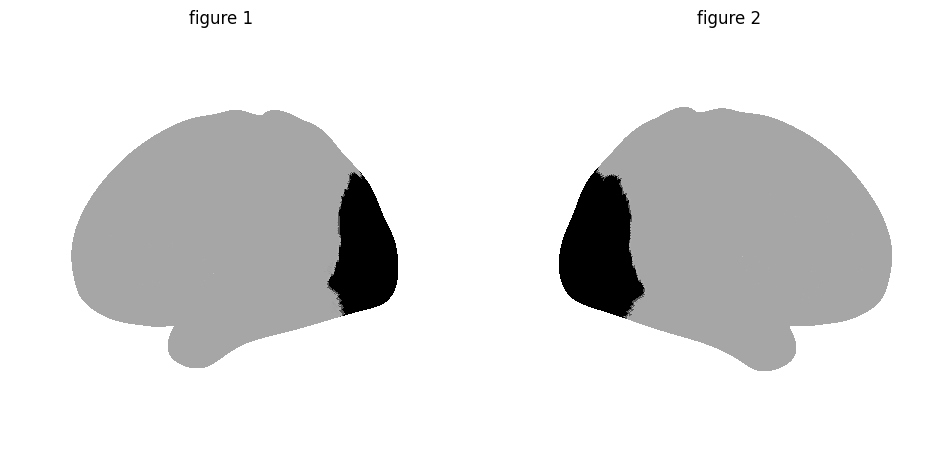

In [5]:
# roi (prefrontal cortex)
ROI_cortex = [5]
atlas_dir = f'{base_dir}/Atlases/tpl-fs32k'
model_name_L = f'{atlas_dir}/HumanLobes.L.label.gii'
model_name_R = f'{atlas_dir}/HumanLobes.R.label.gii'

yeo_parcels = atlas.read_data([model_name_L,model_name_R])
ROI_mask = np.isin(yeo_parcels, ROI_cortex).astype(int)


mask_reshaped = ROI_mask[np.newaxis, :]  # Reshape to (1, 59518)

fig = plot_cortex(mask_reshaped, threshold=0.1, cmap='binary', figsize=(12, 6))
plt.show()


# get indices of voxels in ROI for evaluation later

In [6]:
# find indices where mask is 1 
ROI_indices = np.where(ROI_mask == 1)[0]
len(ROI_indices)

7915

# Load data

In [7]:
MDTB_dataset = DataSetMDTB('/cifs/diedrichsen/data/FunctionalFusion/MDTB')
if not os.path.exists('/cifs/diedrichsen/data/FunctionalFusion/MDTB'):
    MDTB_dataset = DataSetMDTB('Y:/data/FunctionalFusion/MDTB')

data_mdtb_s1_run,info_mdtb_1_run  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='CondRun')
data_mdtb_s1_run[np.isnan(data_mdtb_s1_run)] = 0
data_mdtb_s1_run = data_mdtb_s1_run[:,:,:]


data_mdtb_s1_all,info_mdtb_1_all  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='CondAll')
data_mdtb_s1_all[np.isnan(data_mdtb_s1_all)] = 0
data_mdtb_s1_all = data_mdtb_s1_all[:,:,:]



data_mdtb_s2_all,info_mdtb_2_all  =MDTB_dataset.get_data(space=space,ses_id='ses-s2',type='CondAll')
data_mdtb_s2_all[np.isnan(data_mdtb_s2_all)] = 0


In [8]:
def process_subject_run_preserve_shape(data, info):

    n_subjects, n_conditions, n_voxels = data.shape
    n_runs = info['run'].nunique()
    conditions_per_run = n_conditions // n_runs  # Assuming equal conditions per run

    # The fixed index for 'rest' (29th condition, 0-based index is 28)
    rest_idx = 28

    # Prepare storage for processed data
    processed_data = np.zeros((n_subjects, n_conditions - n_runs, n_voxels))
    updated_info = []

    # Loop over each subject
    for subject_idx in range(n_subjects):
        subject_data = data[subject_idx]  # (conditions, voxels)
        subject_info = info.copy()

        subject_processed_data = []
        
        # Process each run for the current subject
        for run in subject_info['run'].unique():
            run_mask = subject_info['run'] == run
            run_data = subject_data[run_mask]  # Extract data for this run
            run_info = subject_info[run_mask]  # Extract info for this run

            # Extract 'rest' condition and subtract it from the run
            rest_data = run_data[rest_idx]  # Extract 'rest' condition data
            adjusted_run_data = np.delete(run_data, rest_idx, axis=0) - rest_data

            # Remove 'rest' condition from the run's metadata
            adjusted_run_info = run_info.drop(index=run_info.index[rest_idx])

            # Append processed run data and updated info
            subject_processed_data.append(adjusted_run_data)
            updated_info.append(adjusted_run_info)

        # Combine processed runs for the subject
        processed_data[subject_idx] = np.vstack(subject_processed_data)

    # Combine info across all subjects and runs
    updated_info = pd.concat(updated_info, ignore_index=True)

    return processed_data, updated_info

data_mdtb_s1_run, info_mdtb_1_run = process_subject_run_preserve_shape(data_mdtb_s1_run, info_mdtb_1_run)
print(data_mdtb_s1_run.shape)
# find rest index in info file
rest_index = np.where(info_mdtb_1_all['cond_name']=='rest')[0]

# subtract rest from all the data
data_mdtb_s1_rest = data_mdtb_s1_all[:,rest_index,:]

data_mdtb_s1_all = data_mdtb_s1_all - data_mdtb_s1_rest
data_mdtb_s1_all = data_mdtb_s1_all[:,:28,:]
print(data_mdtb_s1_all.shape)

(24, 448, 59518)
(24, 28, 59518)


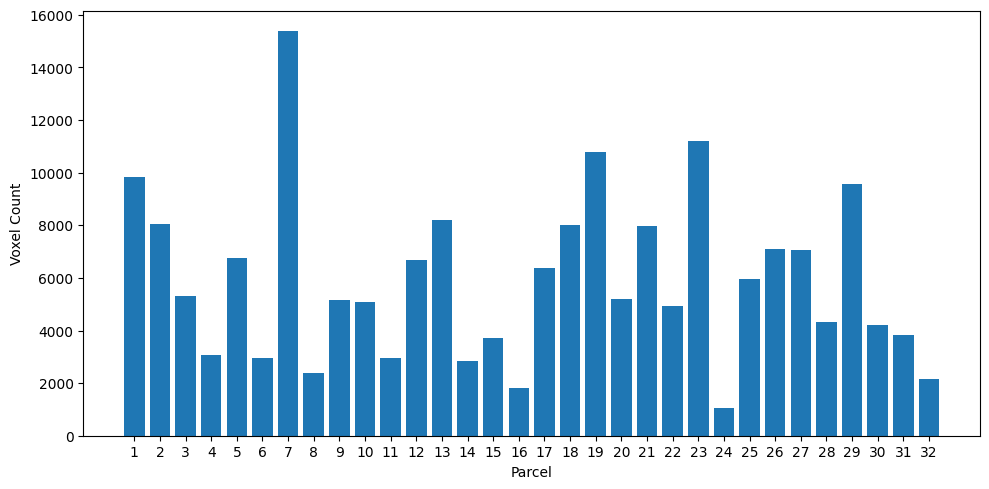

In [9]:
# make random noise data (baseline), project voxels to parcels and count voxel per parcel
data_mdtb_s1_all_noise = np.random.rand(data_mdtb_s1_all.shape[0],data_mdtb_s1_all.shape[1],data_mdtb_s1_all.shape[2])
total_parcel_counts = np.zeros(32)

for subject_data in data_mdtb_s1_all_noise:
    data = subject_data[:, ROI_indices]
    
    data_projected = VL_mdtb_1.T @ data
    data_projected_onehot = ev.get_U_hat_one_hot(data_projected)[0]
    
    total_parcel_counts += np.sum(data_projected_onehot, axis=1)

plt.figure(figsize=(10, 5))
plt.bar(range(1, 33), total_parcel_counts, tick_label=range(1, 33))
plt.xlabel('Parcel')
plt.ylabel('Voxel Count')
plt.tight_layout()
plt.show()

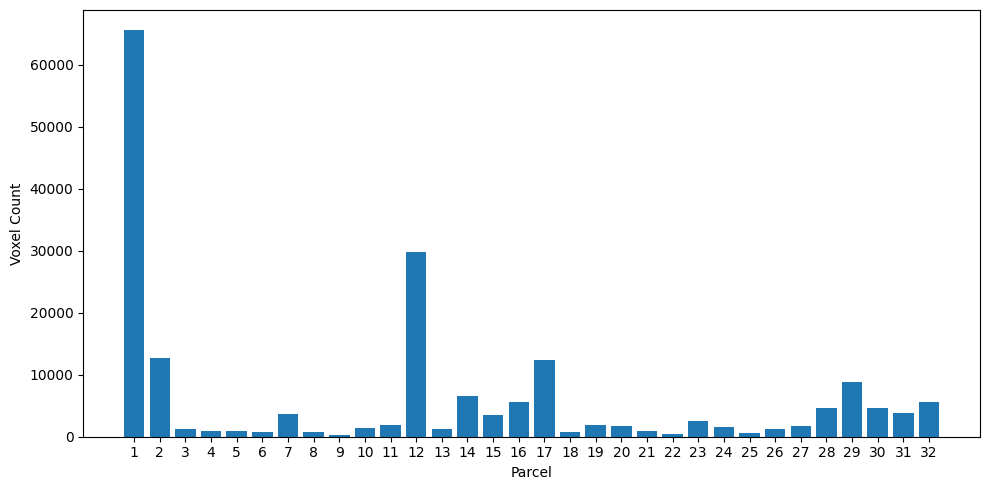

array([ 0, 11,  1, 16, 28, 13, 15, 31], dtype=int64)

In [10]:
# get top 4 parcels with highest voxel counts within ROI
total_parcel_counts = np.zeros(32)

for subject_data in data_mdtb_s1_all:
    data = subject_data[:, ROI_indices]
    
    data_projected = VL_mdtb_1.T @ data
    data_projected_onehot = ev.get_U_hat_one_hot(data_projected)[0]
    
    total_parcel_counts += np.sum(data_projected_onehot, axis=1)

plt.figure(figsize=(10, 5))
plt.bar(range(1, 33), total_parcel_counts, tick_label=range(1, 33))
plt.xlabel('Parcel')
plt.ylabel('Voxel Count')
plt.tight_layout()
plt.show()

# choose 4 parcels with top voxel counts
top_parcels = np.argsort(total_parcel_counts)[::-1][:8]
top_parcels



pretty reasonable S and D region Vs seem to capture the biggest amount of voxels in the frontal cortex ROI

# subset VLib and Vtest to only include parcels with most voxels in ROI

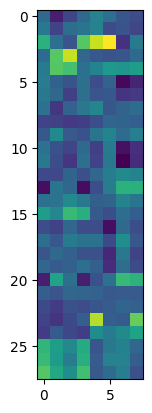

In [11]:
VLib = VL_mdtb_1[:,top_parcels]
plt.imshow(VLib)

In [12]:
vtest =  VL_mdtb_2[:,top_parcels]
vtest.shape

(32, 8)

# Get crossvalidated second moment matrix (GLib)

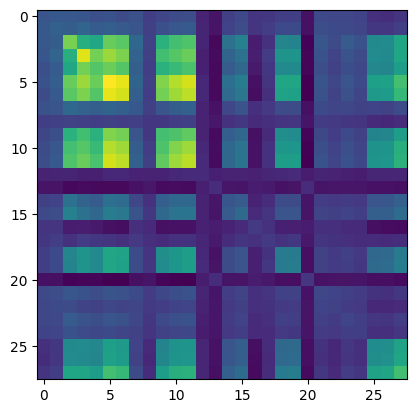

In [13]:
cond_vec = np.tile(np.arange(1, 28 + 1), 16)
part_vec = np.repeat(np.arange(1, 16 + 1), 28)
Gs_list = []
E_list = []
for i in range(data_mdtb_s1_run.shape[0]):
    Gs,E = pcm.util.est_G_crossval(data_mdtb_s1_run[i][:,ROI_indices] , cond_vec, part_vec)
    Gs_list.append(Gs)
    E_list.append(E)

Gs_list = np.stack(Gs_list, 0)
G_Lib = np.mean(Gs_list, axis=0)

plt.imshow(G_Lib)

In [18]:
D = ut.build_combinations(G_Lib, strategy='random',n_iter=1000,n_tasks=4,seed=1,replacement=True)


In [23]:
D_ev = ev.evaluate_dataframe_real_multiregion(D, data_mdtb_s1_all,VLib,data_mdtb_s2_all, vtest,ROI_indices)


Processing combination: 0
Processing combination: 10
Processing combination: 20
Processing combination: 30
Processing combination: 40
Processing combination: 50
Processing combination: 60
Processing combination: 70
Processing combination: 80
Processing combination: 90
Processing combination: 100
Processing combination: 110
Processing combination: 120
Processing combination: 130
Processing combination: 140
Processing combination: 150
Processing combination: 160
Processing combination: 170
Processing combination: 180
Processing combination: 190
Processing combination: 200
Processing combination: 210
Processing combination: 220
Processing combination: 230
Processing combination: 240
Processing combination: 250
Processing combination: 260
Processing combination: 270
Processing combination: 280
Processing combination: 290
Processing combination: 300
Processing combination: 310
Processing combination: 320
Processing combination: 330
Processing combination: 340
Processing combination: 350
Pro

In [26]:
# save dataframe in current repo dataframes folder
save_path = os.path.join(os.getcwd(), '..', 'dataframes')
# D_ev.to_csv(os.path.join(save_path, 'prefrontal_MDTB_s1_s2_top4parcels_8tasks.tsv'), sep='\t', index=False)
# load
# D_ev = pd.read_csv(os.path.join(save_path, 'prefrontal_MDTB_s1_s2_top4parcels_3tasks.tsv'), sep='\t')

In [27]:
len(D_ev)

983

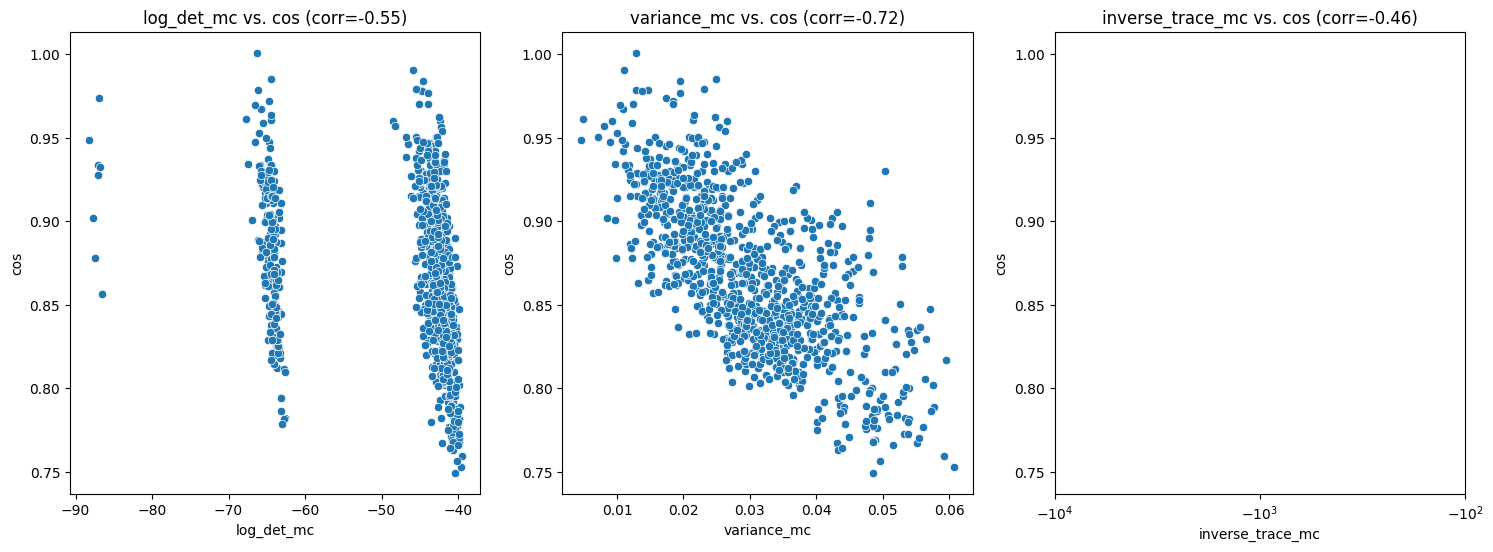

In [28]:

fig, ax = plt.subplots(1, 3, figsize=(18, 6))
sns.scatterplot(data=D_ev, x='log_det_mc', y='cos', ax=ax[0])
sns.scatterplot(data=D_ev, x='variance_mc', y='cos', ax=ax[1])
sns.scatterplot(data=D_ev, x='inverse_trace_mc', y='cos', ax=ax[2])
ax[2].set_xscale('symlog', linthresh=1)
ax[2].set_xlim(-10000, -100)
# add correlation values for each metric and cos
for i, metric in enumerate(['log_det_mc', 'variance_mc', 'inverse_trace_mc']):
    corr, _ = spearmanr(D_ev['cos'], D_ev[metric])
    ax[i].set_title(f'{metric} vs. cos (corr={corr:.2f})')

In [33]:
sample_sizes = range(10, 1000, 5) 
metrics = ['log_det_mc','variance', 'variance_mc', 'inverse_trace_mc']

correlation_data = []
for n in sample_sizes:
    for metric in metrics:
        top_n = D_ev.nlargest(n, metric)
        # find mean of cos values for top n\
        mean_cos = top_n['cos'].mean()        
        correlation_data.append({
            'Sample Size': n,
            'Metric': metric,
            'mean_cos': mean_cos,
        })

correlation_df = pd.DataFrame(correlation_data)




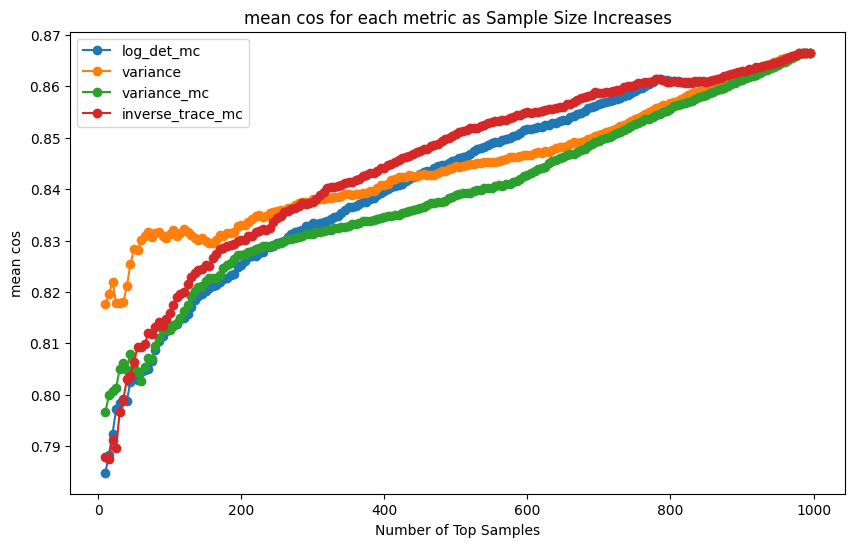

In [ ]:
# Plotting Spearman
plt.figure(figsize=(10, 6))
for metric in metrics:
    subset = correlation_df[correlation_df['Metric'] == metric]
    plt.plot(subset['Sample Size'], subset['mean_cos'], label=metric, marker='o')
plt.title('mean cos for each metric as Sample Size Increases')
plt.xlabel('Number of Top Samples')
plt.ylabel('mean cos')
plt.legend()
plt.show()

In [39]:
# get the cos of the top combination when sorting by variance
top_variance = D_ev.nlargest(5, 'variance')
top_variance_cos = top_variance['cos'].values[4]

# get the cos of the top combination when sorting by log_det_mc
top_log_det_mc = D_ev.nlargest(5, 'log_det_mc')
top_log_det_mc_cos = top_log_det_mc['cos'].values[4]

print(f'cos for top combination when sorting by variance: {top_variance_cos}')
print(f'cos for top combination when sorting by log_det_mc: {top_log_det_mc_cos}')

cos for top combination when sorting by variance: 0.7594340690791427
cos for top combination when sorting by log_det_mc: 0.8019923226257503
